# Análisis de Datos II — Actividad 3: Reducción de dimensionalidad y clustering

**Dataset:** [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) (Zalando Research)

## 1. Selección del dataset



Se eligió **Fashion MNIST**: 70.000 imágenes en escala de grises de 28x28 píxeles de prendas de Zalando, etiquetadas en 10 categorías.

| Etiqueta | Prenda | Etiqueta | Prenda |
|---|---|---|---|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

## 2. Análisis exploratorio y preprocesamiento

### 2.1 Carga del dataset

Se descargan los archivos originales del repositorio oficial de Zalando Research (formato IDX comprimido) y se guardan en `data/fashion-mnist/`. Si ya existen, se reutilizan.

Se unen las particiones de *train* (60.000) y *test* (10.000): en un análisis no supervisado no se entrena un modelo predictivo que haya que evaluar sobre datos no vistos, por lo que la separación original no aporta y se trabaja con el total.

In [1]:
import gzip
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

In [2]:
DATA_DIR = Path("data/fashion-mnist")
BASE_URL = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]


def descargar(nombre):
    ruta = DATA_DIR / nombre
    if not ruta.exists():
        DATA_DIR.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(BASE_URL + nombre, ruta)
    return ruta


def leer_imagenes(nombre):
    """Formato IDX: 16 bytes de cabecera y luego un uint8 por pixel."""
    with gzip.open(descargar(nombre)) as f:
        return np.frombuffer(f.read(), dtype=np.uint8, offset=16).reshape(-1, 28 * 28)


def leer_etiquetas(nombre):
    """Formato IDX: 8 bytes de cabecera y luego un uint8 por etiqueta."""
    with gzip.open(descargar(nombre)) as f:
        return np.frombuffer(f.read(), dtype=np.uint8, offset=8)


X_raw = np.vstack([leer_imagenes(FILES["train_images"]), leer_imagenes(FILES["test_images"])])
y = np.concatenate([leer_etiquetas(FILES["train_labels"]), leer_etiquetas(FILES["test_labels"])])

print(f"X_raw: {X_raw.shape}  dtype={X_raw.dtype}")
print(f"y    : {y.shape}  dtype={y.dtype}")

X_raw: (70000, 784)  dtype=uint8
y    : (70000,)  dtype=uint8


### 2.2 Descripción del dataset

Cada **observación** es una imagen de una prenda, centrada y en escala de grises, de 28x28 píxeles. Para trabajar con técnicas tabulares se la representa como un vector de **784 variables** (la imagen aplanada fila por fila), donde cada variable es la intensidad de un píxel entre 0 (fondo negro) y 255 (máxima intensidad). La variable `y` es la etiqueta de la prenda (0-9) y se reserva para la interpretación.

In [3]:
df = pd.DataFrame(X_raw, columns=[f"px_{i}" for i in range(X_raw.shape[1])])
df["label"] = y
df["prenda"] = pd.Categorical.from_codes(y, CLASS_NAMES)

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]} (784 pixeles + label + prenda)")
df.iloc[:5, list(range(5)) + list(range(400, 405)) + [-2, -1]]

Filas: 70000  |  Columnas: 786 (784 pixeles + label + prenda)


,px_0,px_1,px_2,px_3,px_4,px_400,px_401,px_402,px_403,px_404,label,prenda
0,0,0,0,0,0,0,0,0,0,237,9,Ankle boot
1,0,0,0,0,0,197,199,205,202,205,0,T-shirt/top
2,0,0,0,0,0,12,96,85,87,87,0,T-shirt/top
3,0,0,0,0,0,66,167,140,148,148,3,Dress
4,0,0,0,0,0,0,249,216,217,219,0,T-shirt/top


In [4]:
print("Observaciones por clase:")
print(df["prenda"].value_counts().reindex(CLASS_NAMES).to_string())

Observaciones por clase:
prenda
T-shirt/top    7000
Trouser        7000
Pullover       7000
Dress          7000
Coat           7000
Sandal         7000
Shirt          7000
Sneaker        7000
Bag            7000
Ankle boot     7000


**OBSERVACIONES**
- El dataset está **perfectamente balanceado**: 7.000 imágenes por clase. Ninguna categoría va a dominar el clustering por volumen, y las métricas de comparación contra el target (ARI/AMI) no quedan sesgadas por clases mayoritarias.

### 2.3 Tipos de datos y visualización

Todas las variables de entrada son **numéricas discretas** (`uint8`, 0-255) y comparten escala y significado: son píxeles. La única variable categórica es la etiqueta, que no es una entrada del pipeline. Por eso el análisis de tipos se centra en entender la imagen como dato: cómo se ven las prendas, cómo se distribuyen las intensidades y qué píxeles aportan información.

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Tokens de superficie/texto y color de serie (slot categorico 1), igual que en la actividad 2.
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
C_MAIN = "#2a78d6"
# Escala secuencial de un solo tono (azul), de claro (cerca de cero) a oscuro.
SEQ = LinearSegmentedColormap.from_list(
    "seq_blue", [SURFACE, "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})


def a_imagen(v):
    return np.asarray(v).reshape(28, 28)

#### Ejemplos por clase

Se muestran 8 imágenes al azar de cada categoría (fondo claro y prenda oscura para mejor lectura; es solo una inversión de la escala de grises al graficar).

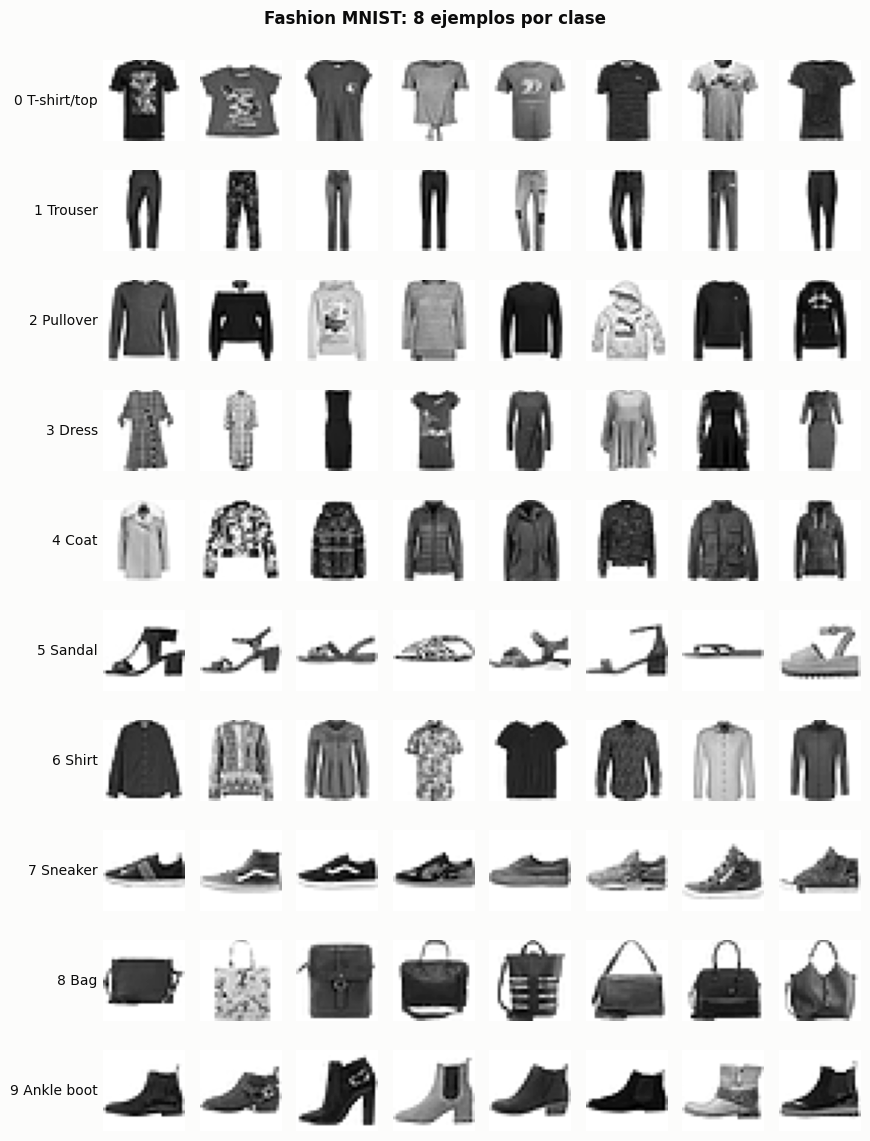

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
N_EJ = 8

fig, axes = plt.subplots(10, N_EJ, figsize=(N_EJ * 1.1, 10 * 1.15))
for k, nombre in enumerate(CLASS_NAMES):
    idx = rng.choice(np.flatnonzero(y == k), N_EJ, replace=False)
    for j, i in enumerate(idx):
        ax = axes[k, j]
        ax.imshow(a_imagen(X_raw[i]), cmap="gray_r", vmin=0, vmax=255)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
    axes[k, 0].set_ylabel(f"{k} {nombre}", rotation=0, ha="right", va="center", color=INK)
fig.suptitle("Fashion MNIST: 8 ejemplos por clase", fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- Las prendas están **centradas y normalizadas en tamaño**, con fondo negro (0). Esto hace que un mismo píxel represente aproximadamente la misma zona de la prenda en todas las imágenes, condición necesaria para que la representación "píxel a píxel" tenga sentido sin extraer features adicionales.
- A simple vista se distinguen tres familias de siluetas: **prendas superiores** (T-shirt, Pullover, Coat, Shirt, Dress), **calzado** (Sandal, Sneaker, Ankle boot) y dos formas muy particulares (**Trouser**, con dos piernas separadas, y **Bag**, con forma rectangular y a veces con asa).
- Dentro de las prendas superiores, **Pullover, Coat y Shirt** son visualmente muy parecidas: se diferencian por detalles (cierre, botones, cuello, textura) más que por la silueta. Es un primer indicio a favor de H2.

#### Distribución de intensidades

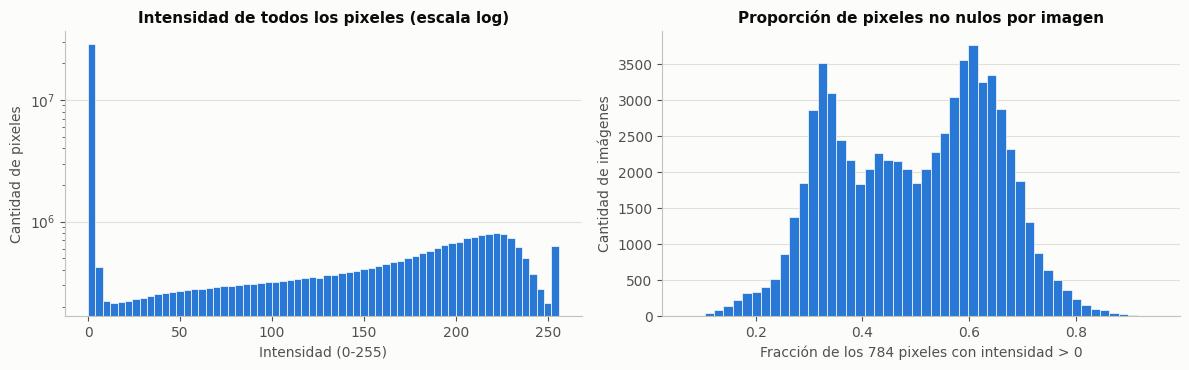

Pixeles en 0 (fondo)   :  50.2%
Pixeles saturados (255):   0.8%
Ocupación media        :  49.8%  (min 6.9%, max 95.2%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].hist(X_raw.ravel(), bins=64, range=(0, 256), color=C_MAIN, edgecolor=SURFACE, linewidth=0.5)
axes[0].set_yscale("log")
axes[0].set_title("Intensidad de todos los pixeles (escala log)")
axes[0].set_xlabel("Intensidad (0-255)")
axes[0].set_ylabel("Cantidad de pixeles")
axes[0].grid(axis="y")
axes[0].set_axisbelow(True)

# Proporcion de pixeles encendidos (>0) por imagen: cuanta "superficie" ocupa la prenda.
ocupacion = (X_raw > 0).mean(axis=1)
axes[1].hist(ocupacion, bins=50, color=C_MAIN, edgecolor=SURFACE, linewidth=0.5)
axes[1].set_title("Proporción de pixeles no nulos por imagen")
axes[1].set_xlabel("Fracción de los 784 pixeles con intensidad > 0")
axes[1].set_ylabel("Cantidad de imágenes")
axes[1].grid(axis="y")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"Pixeles en 0 (fondo)   : {(X_raw == 0).mean():6.1%}")
print(f"Pixeles saturados (255): {(X_raw == 255).mean():6.1%}")
print(f"Ocupación media        : {ocupacion.mean():6.1%}  (min {ocupacion.min():.1%}, max {ocupacion.max():.1%})")

**OBSERVACIONES**
- La distribución de intensidades es **fuertemente bimodal y dispersa**: alrededor de la mitad de los píxeles del dataset valen exactamente 0 (fondo) y el resto se reparte a lo largo de todo el rango, con muy pocos píxeles saturados.
- La fracción de la imagen ocupada por la prenda varía mucho (de 7% a 95%) y su distribución es **bimodal**: un modo cerca de 0,33 (prendas angostas o bajas, como calzado y pantalones) y otro cerca de 0,60 (prendas que llenan el cuadro, como abrigos, buzos y bolsos). Es un primer indicio de macro-grupos en los datos. La cantidad de "tinta" va a ser, previsiblemente, una de las direcciones principales de variación (se retoma más abajo).

#### Imagen promedio y variabilidad por píxel

La imagen promedio muestra dónde suele haber prenda; el desvío estándar por píxel muestra **qué píxeles varían entre imágenes**, que son los únicos que aportan información para distinguirlas.

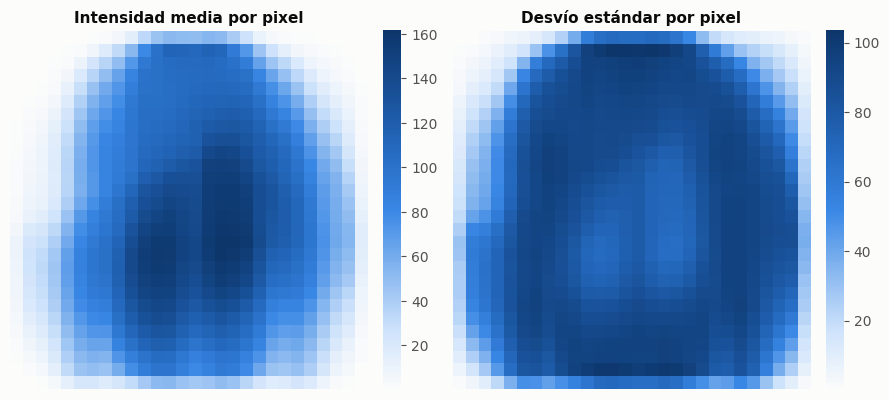

Desvío estándar por pixel: min 0.09  |  mediana 81.3  |  max 103.6
Pixeles constantes (std = 0): 0
Pixeles casi constantes (std < 5): 19


In [8]:
media_px = X_raw.mean(axis=0)
std_px = X_raw.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, datos, titulo in [
    (axes[0], media_px, "Intensidad media por pixel"),
    (axes[1], std_px, "Desvío estándar por pixel"),
]:
    im = ax.imshow(a_imagen(datos), cmap=SEQ)
    ax.set_title(titulo)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).outline.set_visible(False)
plt.tight_layout()
plt.show()

print(f"Desvío estándar por pixel: min {std_px.min():.2f}  |  mediana {np.median(std_px):.1f}  |  max {std_px.max():.1f}")
print(f"Pixeles constantes (std = 0): {(std_px == 0).sum()}")
print(f"Pixeles casi constantes (std < 5): {(std_px < 5).sum()}")

**OBSERVACIONES**
- La imagen media es una **superposición borrosa** de todas las siluetas, con más intensidad en el centro y la mitad inferior del cuadro (donde coinciden calzado, pantalones y el cuerpo de las prendas superiores).
- No hay píxeles estrictamente constantes, pero las **esquinas y los bordes laterales** tienen un desvío casi nulo: son fondo en prácticamente todas las imágenes. Son dimensiones que no aportan información y que una técnica como PCA va a descartar naturalmente (explican una porción ínfima de la varianza).
- La variabilidad es máxima en una **franja que rodea el centro** (hombros, mangas, costados y base), que es justamente donde se diferencian las siluetas: ahí hay prenda en algunas clases y fondo en otras. El centro varía algo menos porque casi todas las prendas lo ocupan.

#### Imagen promedio por clase

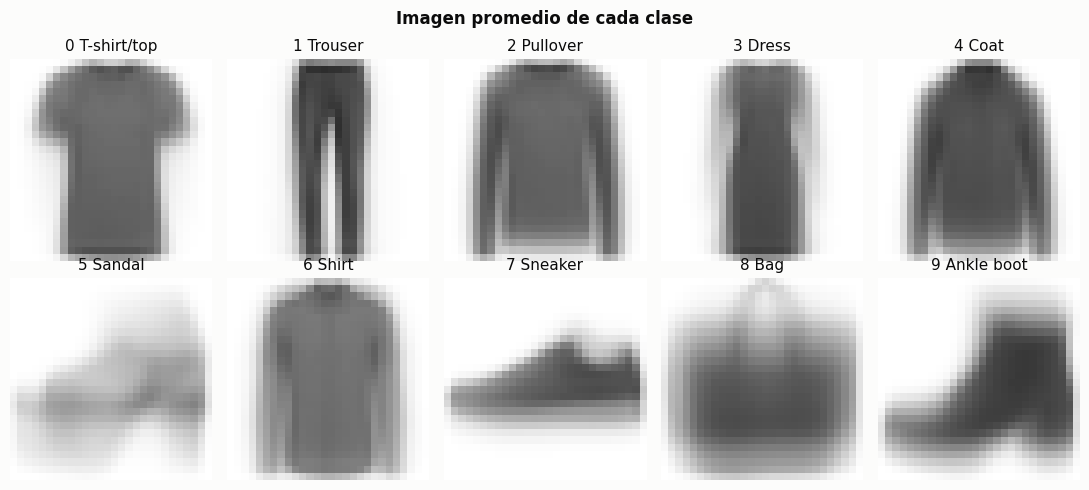

In [9]:
medias_clase = np.array([X_raw[y == k].mean(axis=0) for k in range(10)])

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(a_imagen(medias_clase[k]), cmap="gray_r", vmin=0, vmax=255)
    ax.set_title(f"{k} {CLASS_NAMES[k]}", fontweight="normal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
fig.suptitle("Imagen promedio de cada clase", fontweight="bold")
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- Los promedios por clase son **nítidos**: la variabilidad intra-clase en forma y posición es baja, y cada categoría tiene un "prototipo" reconocible. Esto sugiere que algoritmos basados en centroides (como K-means) pueden recuperar parte de la estructura de clases.
- Pullover, Coat y Shirt tienen prototipos casi idénticos (silueta de mangas largas); T-shirt y Dress se distinguen por las mangas cortas y el largo, respectivamente. En calzado, Sneaker y Ankle boot se diferencian por la altura de la caña, y Sandal por su aspecto calado (menor intensidad media).

#### Cantidad de "tinta" por clase

Se resume cada imagen con un único número, su intensidad media (entre 0 y 1). Es una variable simple pero con significado físico: cuánta superficie ocupa la prenda y qué tan clara es la tela.

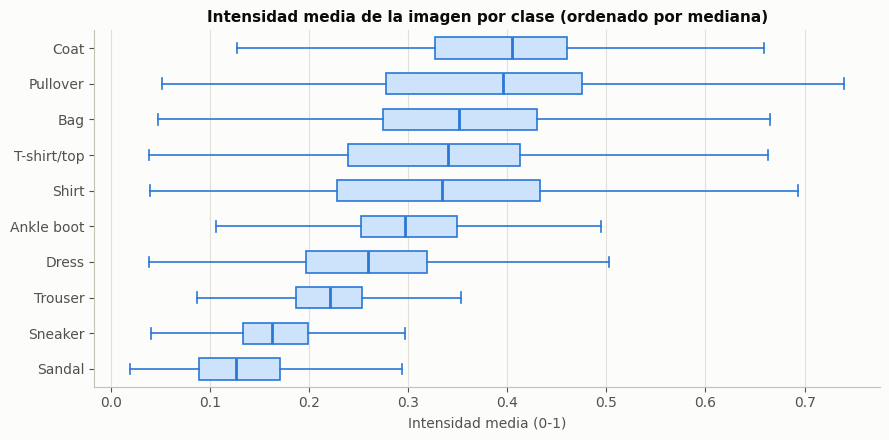

,mean,50%,std
prenda,,,
Sandal,0.137,0.126,0.062
Sneaker,0.168,0.162,0.050
Trouser,0.223,0.221,0.057
Dress,0.259,0.260,0.084
Ankle boot,0.301,0.296,0.072
Shirt,0.332,0.334,0.129
T-shirt/top,0.326,0.340,0.113
Bag,0.354,0.351,0.113
Pullover,0.376,0.396,0.128


In [10]:
df["intensidad_media"] = X_raw.mean(axis=1) / 255
orden = df.groupby("prenda", observed=True)["intensidad_media"].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot(
    [df.loc[df["prenda"] == c, "intensidad_media"] for c in orden],
    vert=False, labels=list(orden), widths=0.6, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="#cde2fb", edgecolor=C_MAIN, linewidth=1.2),
    medianprops=dict(color=C_MAIN, linewidth=2),
    whiskerprops=dict(color=C_MAIN, linewidth=1.2), capprops=dict(color=C_MAIN, linewidth=1.2),
)
ax.set_title("Intensidad media de la imagen por clase (ordenado por mediana)")
ax.set_xlabel("Intensidad media (0-1)")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

df.groupby("prenda", observed=True)["intensidad_media"].describe()[["mean", "50%", "std"]].round(3).loc[orden]

**OBSERVACIONES**
- La cantidad de tinta separa claramente al **calzado** (Sandal y Sneaker con medianas cercanas a 0,13-0,16) de las **prendas superiores y bolsos** (Pullover y Coat alrededor de 0,40). Trouser y Dress quedan en una zona intermedia por ser prendas angostas.
- Sin embargo, las distribuciones de las clases superiores (T-shirt, Shirt, Bag, Pullover, Coat) **se solapan casi por completo**: esta variable alcanza para separar familias, pero no categorías. Refuerza H1 (macro-grupos) y H2 (solapamiento entre prendas superiores).

#### Similitud entre clases

Para cuantificar el solapamiento visto en los prototipos, se calcula la **similitud coseno entre las imágenes promedio** de cada par de clases (1 = prototipos idénticos). Es un análisis descriptivo sobre las etiquetas; no participa en la reducción de dimensionalidad ni en el clustering.

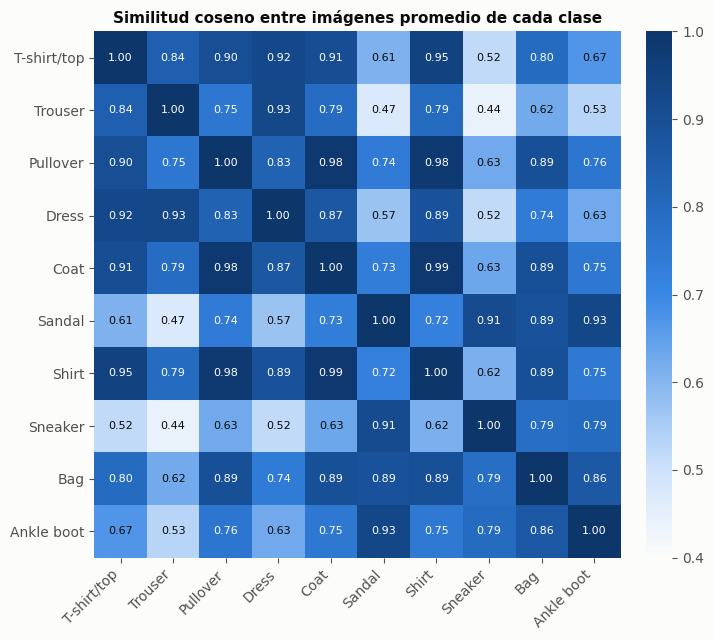

Pares de clases más parecidos:
Coat         Shirt         0.988
Pullover     Coat          0.985
             Shirt         0.983
T-shirt/top  Shirt         0.949
Sandal       Ankle boot    0.928
Trouser      Dress         0.925


In [11]:
normas = np.linalg.norm(medias_clase, axis=1, keepdims=True)
sim = (medias_clase / normas) @ (medias_clase / normas).T
sim_df = pd.DataFrame(sim, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(sim, cmap=SEQ, vmin=0.4, vmax=1)
ax.set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(10), CLASS_NAMES)
for i in range(10):
    for j in range(10):
        # Texto en tinta primaria o blanco segun la luminosidad de la celda.
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if sim[i, j] > 0.72 else INK)
ax.spines[:].set_visible(False)
ax.set_title("Similitud coseno entre imágenes promedio de cada clase")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).outline.set_visible(False)
plt.tight_layout()
plt.show()

pares = (
    sim_df.where(np.triu(np.ones_like(sim, dtype=bool), k=1)).stack()
    .rename("similitud").sort_values(ascending=False)
)
print("Pares de clases más parecidos:")
print(pares.head(6).round(3).to_string())

**OBSERVACIONES**
- Aparecen con claridad dos bloques de alta similitud: **prendas superiores** (T-shirt, Pullover, Dress, Coat, Shirt) y **calzado** (Sandal, Sneaker, Ankle boot), con similitudes cruzadas bastante menores entre ambos bloques (0,52-0,76). Es consistente con H1.
- Los pares más parecidos son **Coat-Shirt (0,99), Pullover-Coat (0,98) y Pullover-Shirt (0,98)**: en el espacio de píxeles, sus prototipos son prácticamente indistinguibles. Es esperable que el clustering los mezcle (H2).
- **Bag** tiene similitud alta con ambos bloques (0,89 con Pullover, Coat, Shirt y Sandal; 0,86 con Ankle boot), por su forma "llena" y rectangular; es candidato a quedar en una zona intermedia o a formar su propio grupo.
- **Trouser** es la clase más alejada del calzado (0,44-0,53) y la más cercana a Dress (0,93), por compartir una silueta vertical y angosta.

### 2.4 Representación de los datos

A diferencia del caso de texto, las imágenes ya vienen como una matriz numérica, por lo que la representación elegida es la más directa: **cada imagen aplanada como un vector de 784 intensidades**.

Alternativas descartadas:
- **Embeddings de una red convolucional preentrenada** (por ejemplo, ResNet): capturarían mejor texturas y detalles, pero agregan una dependencia pesada (PyTorch/TensorFlow) y una "caja negra" previa que dificulta interpretar los resultados en términos de la imagen. Además, el objetivo de la actividad es justamente que la reducción de dimensionalidad (punto 3.a) construya la representación compacta.
- **Features manuales** (cantidad de tinta, alto/ancho de la silueta, simetría, etc.): son interpretables pero se pierde información y se introduce un sesgo de diseño.

La representación en píxeles mantiene el vínculo directo con la imagen: los componentes de PCA y los centroides de los clusters se pueden volver a graficar como imágenes de 28x28, lo que simplifica la interpretación.

### 2.5 Valores faltantes y duplicados

In [12]:
n_nan = np.isnan(X_raw.astype(np.float32)).sum()
fuera_rango = ((X_raw < 0) | (X_raw > 255)).sum()
_, n_unicas = np.unique(X_raw, axis=0, return_counts=True)
n_dup = len(X_raw) - len(n_unicas)
etiquetas_validas = np.isin(y, range(10)).all()

pd.DataFrame(
    {
        "chequeo": ["Valores faltantes (NaN)", "Pixeles fuera de [0, 255]",
                    "Imágenes duplicadas exactas", "Etiquetas fuera de 0-9"],
        "resultado": [n_nan, fuera_rango, n_dup, 0 if etiquetas_validas else "hay"],
    }
)

,chequeo,resultado
0,Valores faltantes (NaN),0
1,"Pixeles fuera de [0, 255]",0
2,Imágenes duplicadas exactas,0
3,Etiquetas fuera de 0-9,0


**OBSERVACIONES**
- **No hay valores faltantes** ni intensidades fuera de rango: el dataset es una base curada y no requiere imputación.
- **No hay imágenes duplicadas exactas** (ni siquiera entre train y test), así que la unión de ambas particiones no introduce repetidos que puedan formar clusters artificiales.

### 2.6 Normalización / estandarización

Las técnicas del punto 3 (PCA/SVD, K-means, DBSCAN, UMAP) se basan en **distancias euclídeas o en varianzas**, por lo que la escala de las variables importa. Se evaluaron dos opciones:

1. **Reescalar a [0, 1]** dividiendo por 255. Mantiene las proporciones entre píxeles: uno que casi no varía (esquina) sigue pesando poco y uno del contorno de la prenda sigue pesando mucho.
2. **Estandarizar cada píxel** (media 0 y desvío 1). Es la opción habitual en datos tabulares con unidades distintas, pero acá todas las variables ya están en la misma unidad. Estandarizar le daría a los píxeles casi constantes de los bordes (desvío < 5 sobre 255) **el mismo peso** que a los del contorno, amplificando ruido de unos pocos píxeles aislados.

Se elige la **opción 1**. PCA centra los datos internamente, por lo que no hace falta restar la media de antemano.

In [13]:
X = (X_raw / 255.0).astype(np.float32)

print(f"X (reescalado): min={X.min():.1f}  max={X.max():.1f}  media={X.mean():.3f}  dtype={X.dtype}")
print()

# Que pasaria si se estandarizara: se compara un pixel de la esquina con uno del centro.
esquina, centro = 0, 14 * 28 + 14  # pixel (0, 0) y pixel (14, 14)
print("Rango de valores de dos pixeles según la transformación:")
for nombre, j in [("esquina (0,0) ", esquina), ("centro (14,14)", centro)]:
    z = (X_raw[:, j] - media_px[j]) / std_px[j]
    print(f"  {nombre} -> reescalado: [{X[:, j].min():.2f}, {X[:, j].max():.2f}]"
          f"  |  estandarizado: [{z.min():6.1f}, {z.max():6.1f}]"
          f"  |  imágenes con valor != 0: {(X_raw[:, j] > 0).mean():6.2%}")

X (reescalado): min=0.0  max=1.0  media=0.286  dtype=float32

Rango de valores de dos pixeles según la transformación:
  esquina (0,0)  -> reescalado: [0.00, 0.06]  |  estandarizado: [  -0.0,  183.2]  |  imágenes con valor != 0:  0.02%
  centro (14,14) -> reescalado: [0.00, 1.00]  |  estandarizado: [  -1.8,    1.5]  |  imágenes con valor != 0: 87.92%


**OBSERVACIONES**
- Con el reescalado todos los píxeles quedan en [0, 1] y conservan su peso relativo.
- La comparación muestra el problema de estandarizar: el píxel de la esquina, que es fondo en casi todas las imágenes, pasaría a tomar valores extremos (decenas o cientos de desvíos) en las pocas imágenes donde no es cero. En distancia euclídea, esos valores dominarían a los píxeles realmente informativos.

### 2.7 Muestra de trabajo

Algunas etapas del punto 3 escalan mal con 70.000 observaciones: el coeficiente de **Silhouette** requiere todas las distancias entre pares (orden n², unos 4.900 millones de pares) y **DBSCAN** y **UMAP** son costosos en tiempo y memoria. Para mantener tiempos de ejecución razonables se toma una **muestra estratificada de 10.000 imágenes** (1.000 por clase), que preserva el balance de clases. La estratificación usa la etiqueta solo para elegir qué filas entran en la muestra; la etiqueta no se incorpora como variable.

El dataset completo `X` queda disponible por si se quiere validar algún resultado (por ejemplo, ajustar PCA con los 70.000 casos).

In [14]:
N_POR_CLASE = 1_000

rng = np.random.default_rng(RANDOM_STATE)
idx_muestra = np.sort(np.concatenate([
    rng.choice(np.flatnonzero(y == k), N_POR_CLASE, replace=False) for k in range(10)
]))

X_work = X[idx_muestra]
y_work = y[idx_muestra]  # solo para interpretacion posterior

print(f"X_work: {X_work.shape}  |  y_work: {y_work.shape}")
print("Imágenes por clase en la muestra:", np.bincount(y_work).tolist())
print(f"Intensidad media: dataset completo {X.mean():.4f}  |  muestra {X_work.mean():.4f}")

X_work: (10000, 784)  |  y_work: (10000,)
Imágenes por clase en la muestra: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
Intensidad media: dataset completo 0.2862  |  muestra 0.2852


### 2.8 Resumen del preprocesamiento

| Paso | Decisión |
|---|---|
| Datos | 70.000 imágenes (train + test unidos), 10 clases balanceadas |
| Representación | Vector de 784 píxeles por imagen (imagen 28x28 aplanada) |
| Faltantes / duplicados | No hay; no se requiere imputación ni limpieza |
| Escala | Reescalado a [0, 1] (división por 255); sin estandarización por píxel |
| Target | `y` / `y_work` separado, solo para interpretación posterior |
| Muestra de trabajo | `X_work`: 10.000 imágenes estratificadas (1.000 por clase) |

**Conclusiones del EDA y relación con las hipótesis**

- **H1 (macro-grupos por silueta):** los prototipos por clase, la cantidad de tinta y la similitud entre clases muestran dos bloques claros, prendas superiores y calzado, con Trouser y Bag como formas distintivas. Se espera que el clustering los recupere.
- **H2 (solapamiento Pullover / Coat / Shirt):** sus prototipos tienen similitud coseno de 0,98-0,99; es muy probable que queden mezclados.
- **H3 (compresión con pocas componentes):** la baja varianza en bordes y la fuerte redundancia entre píxeles vecinos anticipan que PCA podrá retener la mayor parte de la varianza con un número reducido de componentes. Se verifica en el punto 3.a.

## 3. Reducción de dimensionalidad y clustering

Todo este punto trabaja sobre `X_work` (10.000 imágenes). La etiqueta `y_work` **no** se usa para ajustar PCA ni los clusters, ni para elegir sus hiperparámetros; solo aparece en la evaluación externa (ARI/AMI) y en la interpretación.

### 3.a Reducción de dimensionalidad con PCA

Se usa **PCA**: es lineal, rápido y sus componentes son vectores de 784 píxeles, así que se pueden graficar como imágenes e interpretar. El número de componentes se fija por la varianza explicada acumulada.

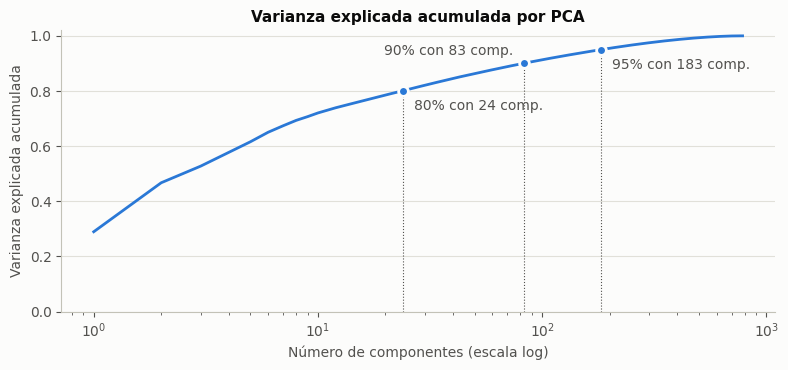

Varianza explicada por las 5 primeras componentes: [0.29, 0.178, 0.06, 0.05, 0.038]


In [15]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE).fit(X_work)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_para = {u: int(np.searchsorted(var_acum, u) + 1) for u in (0.80, 0.90, 0.95)}

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(np.arange(1, len(var_acum) + 1), var_acum, color=C_MAIN, linewidth=2)
for u, n in n_para.items():
    ax.plot([n, n], [0, u], color=INK_2, linewidth=0.8, linestyle=":")
    ax.plot(n, u, "o", color=C_MAIN, markersize=7, markeredgecolor=SURFACE, markeredgewidth=2)
    # La etiqueta del 90% va a la izquierda para no pisar la del 95%.
    izq = u == 0.90
    ax.annotate(f"{u:.0%} con {n} comp.", (n, u), xytext=(-8, 6) if izq else (8, -14),
                textcoords="offset points", ha="right" if izq else "left", color=INK_2)
ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_title("Varianza explicada acumulada por PCA")
ax.set_xlabel("Número de componentes (escala log)")
ax.set_ylabel("Varianza explicada acumulada")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("Varianza explicada por las 5 primeras componentes:", [round(float(v), 3) for v in pca_full.explained_variance_ratio_[:5]])

Se retiene el **90% de la varianza**. Para ver qué capturan las componentes se grafican las primeras 6 como imágenes (azul: peso negativo, rojo: positivo) y la reconstrucción de algunas prendas con las componentes retenidas.

Dimensión: 784 -> 83  |  varianza retenida: 90.1%


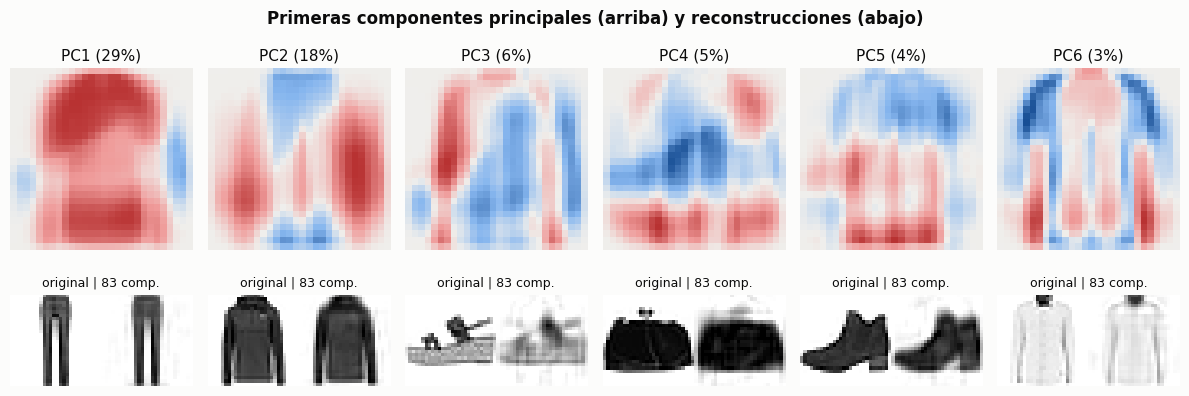

In [16]:
N_COMP = n_para[0.90]
pca = PCA(n_components=N_COMP, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_work)
print(f"Dimensión: {X_work.shape[1]} -> {Z.shape[1]}  |  varianza retenida: {pca.explained_variance_ratio_.sum():.1%}")

DIV = LinearSegmentedColormap.from_list("div", ["#184f95", "#86b6ef", "#f0efec", "#ef9a99", "#b83232"])

fig, axes = plt.subplots(2, 6, figsize=(12, 4.6))
for i, ax in enumerate(axes[0]):
    comp = pca.components_[i]
    lim = np.abs(comp).max()
    ax.imshow(a_imagen(comp), cmap=DIV, vmin=-lim, vmax=lim)
    ax.set_title(f"PC{i + 1} ({pca.explained_variance_ratio_[i]:.0%})", fontweight="normal")

ejemplos = [np.flatnonzero(y_work == k)[0] for k in (1, 4, 5, 8, 9, 6)]
X_rec = pca.inverse_transform(Z[ejemplos])
for ax, i, rec in zip(axes[1], ejemplos, X_rec):
    ax.imshow(np.hstack([a_imagen(X_work[i]), a_imagen(rec)]), cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"original | {N_COMP} comp.", fontweight="normal", fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)
fig.suptitle("Primeras componentes principales (arriba) y reconstrucciones (abajo)", fontweight="bold")
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- **H3 se confirma:** 24 componentes retienen el 80% de la varianza y **83 componentes el 90%**, es decir, se conserva el 90% de la información usando apenas el 10% de las dimensiones originales.
- **PC1 (29%)** tiene pesos positivos en toda la zona central: mide la **cantidad de tinta**, es decir, qué superficie ocupa la prenda y qué tan oscura es. Es la misma variable que separaba familias en el EDA. **PC2 (18%)** contrasta los costados de la imagen (mangas) con la franja central superior y la base: distingue prendas anchas con mangas de siluetas angostas o bajas. Las siguientes capturan detalles más finos (asimetrías, altura del borde inferior, piernas del pantalón).
- Las reconstrucciones con 83 componentes **conservan la silueta y el tono** de cada prenda y pierden detalles finos (tiras de la sandalia, estampados), que no son necesarios para agrupar por forma.

### 3.b Clustering

Se comparan dos algoritmos de naturaleza distinta sobre `Z`:

- **K-means**: particional, basado en centroides; supone grupos compactos y de tamaño similar.
- **Clustering jerárquico aglomerativo (Ward)**: une en forma ascendente los pares de grupos que menos aumentan la varianza intra-cluster; no depende de una inicialización aleatoria.

Se descartó **DBSCAN**: con 83 dimensiones las distancias entre puntos tienden a parecerse (maldición de la dimensionalidad) y no hay un `eps` que separe regiones densas sin dejar casi todo como ruido o en un único cluster.

**Elección de k.** Se recorre k = 2..12 y se miran dos métricas internas, que no usan la etiqueta: **Silhouette** (mayor es mejor) y **Davies-Bouldin** (menor es mejor).

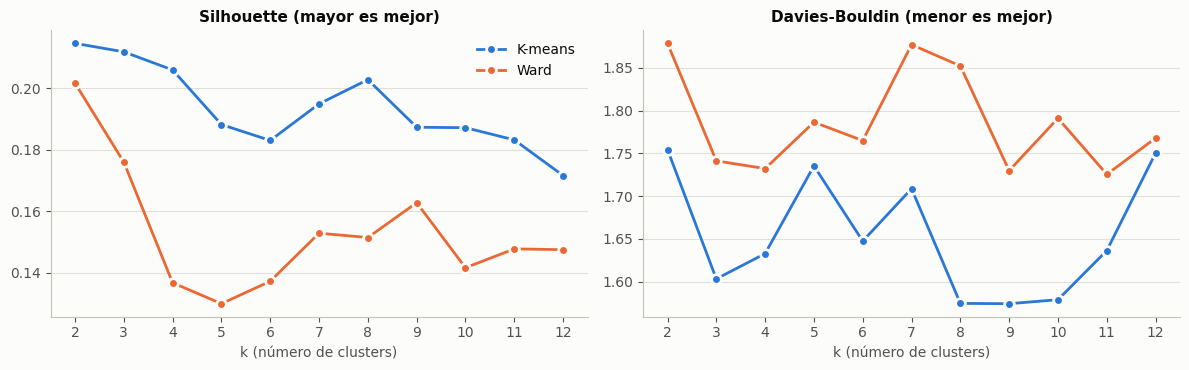

k                          2      3      4      5      6      7      8      9      10     11     12
               modelo                                                                              
silhouette     K-means  0.215  0.212  0.206  0.188  0.183  0.195  0.203  0.187  0.187  0.183  0.172
               Ward     0.202  0.176  0.137  0.130  0.137  0.153  0.151  0.163  0.142  0.148  0.147
davies_bouldin K-means  1.754  1.603  1.633  1.735  1.647  1.709  1.575  1.574  1.579  1.636  1.750
               Ward     1.879  1.741  1.732  1.786  1.765  1.877  1.852  1.730  1.791  1.725  1.768

In [17]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score,
                             calinski_harabasz_score, davies_bouldin_score, silhouette_score)

C_WARD = "#eb6834"  # slot categorico 2
MODELOS = {
    "K-means": lambda k: KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE),
    "Ward": lambda k: AgglomerativeClustering(n_clusters=k, linkage="ward"),
}

K_RANGO = range(2, 13)
barrido = []
for k in K_RANGO:
    for nombre, modelo in MODELOS.items():
        etiquetas = modelo(k).fit_predict(Z)
        barrido.append({"k": k, "modelo": nombre,
                        "silhouette": silhouette_score(Z, etiquetas),
                        "davies_bouldin": davies_bouldin_score(Z, etiquetas)})
barrido = pd.DataFrame(barrido)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, metrica, titulo in [(axes[0], "silhouette", "Silhouette (mayor es mejor)"),
                            (axes[1], "davies_bouldin", "Davies-Bouldin (menor es mejor)")]:
    for nombre, color in [("K-means", C_MAIN), ("Ward", C_WARD)]:
        d = barrido[barrido["modelo"] == nombre]
        ax.plot(d["k"], d[metrica], color=color, linewidth=2, marker="o", markersize=7,
                markeredgecolor=SURFACE, markeredgewidth=2, label=nombre)
    ax.set_title(titulo)
    ax.set_xlabel("k (número de clusters)")
    ax.set_xticks(list(K_RANGO))
    ax.grid(axis="y")
    ax.set_axisbelow(True)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

barrido.pivot(index="k", columns="modelo", values=["silhouette", "davies_bouldin"]).round(3).T

**OBSERVACIONES**
- Las dos métricas internas son **bajas y bastante planas** (Silhouette entre 0,13 y 0,22): no hay grupos nítidamente separados sino regiones que se solapan, coherente con la similitud alta entre clases vista en el EDA.
- El máximo global de Silhouette está en k = 2-3, pero esa partición solo separa macro-familias. Para K-means aparece un **máximo local en k = 8** (0,203) que coincide con el **mínimo de Davies-Bouldin** (1,575). Se elige **k = 8** como la partición más fina con buenas métricas internas y se usa el mismo k en ambos algoritmos para compararlos en igualdad de condiciones.
- Para todo k, Ward queda por debajo de K-means en Silhouette y por encima en Davies-Bouldin.

In [18]:
K = 8
etiquetas = {nombre: modelo(K).fit_predict(Z) for nombre, modelo in MODELOS.items()}
for nombre, l in etiquetas.items():
    print(f"{nombre:8s} tamaños de cluster: {sorted(np.bincount(l).tolist(), reverse=True)}")

K-means  tamaños de cluster: [1797, 1771, 1767, 1444, 1367, 1065, 398, 391]
Ward     tamaños de cluster: [1846, 1720, 1384, 1312, 1199, 1149, 912, 478]


### 3.c Evaluación y comparación

Se combinan métricas **internas** (cohesión y separación, sin etiqueta) y **externas** (ARI y AMI: concordancia con las 10 clases reales, 0 = azar y 1 = coincidencia perfecta). Las externas solo se usan para evaluar, no intervinieron en la elección de k.

In [19]:
evaluacion = pd.DataFrame({
    nombre: {
        "silhouette (+)": silhouette_score(Z, l),
        "davies_bouldin (-)": davies_bouldin_score(Z, l),
        "calinski_harabasz (+)": calinski_harabasz_score(Z, l),
        "ARI (+)": adjusted_rand_score(y_work, l),
        "AMI (+)": adjusted_mutual_info_score(y_work, l),
    }
    for nombre, l in etiquetas.items()
}).round(3)
evaluacion

,K-means,Ward
silhouette (+),0.203,0.151
davies_bouldin (-),1.575,1.852
calinski_harabasz (+),1819.495,1525.849
ARI (+),0.363,0.378
AMI (+),0.527,0.569


La **matriz de contingencia** (cluster x clase) muestra cómo se reparte cada clase entre los clusters. Para facilitar la lectura, los clusters se reordenan según su clase predominante (es solo un cambio de nombre posterior al clustering).

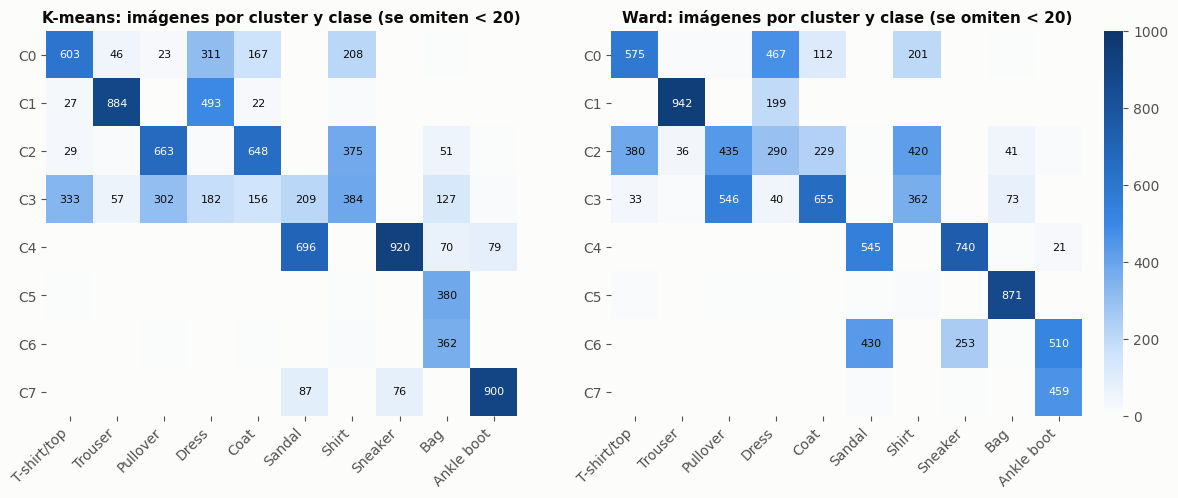

In [20]:
def reordenar(l):
    """Renumera los clusters por su clase predominante (solo presentacion)."""
    tabla = pd.crosstab(l, y_work)
    orden = tabla.idxmax(axis=1).sort_values(kind="stable").index
    mapa = {viejo: nuevo for nuevo, viejo in enumerate(orden)}
    return np.vectorize(mapa.get)(l)


etiquetas = {nombre: reordenar(l) for nombre, l in etiquetas.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (nombre, l) in zip(axes, etiquetas.items()):
    tabla = pd.crosstab(l, y_work).reindex(columns=range(10), fill_value=0)
    im = ax.imshow(tabla.values, cmap=SEQ, vmin=0, vmax=1000, aspect="auto")
    for i in range(tabla.shape[0]):
        for j in range(10):
            v = tabla.values[i, j]
            if v >= 20:
                ax.text(j, i, v, ha="center", va="center", fontsize=8, color="white" if v > 450 else INK)
    ax.set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(K), [f"C{i}" for i in range(K)])
    ax.spines[:].set_visible(False)
    ax.set_title(f"{nombre}: imágenes por cluster y clase (se omiten < 20)")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02).outline.set_visible(False)
plt.show()

**OBSERVACIONES**
- **Métricas internas:** K-means es mejor en las tres (Silhouette 0,203 vs 0,151; Davies-Bouldin 1,575 vs 1,852; Calinski-Harabasz 1.819 vs 1.526): sus clusters son más compactos y están más separados.
- **Métricas externas:** Ward concuerda algo más con las clases reales (ARI 0,378 vs 0,363; AMI 0,569 vs 0,527), aunque la diferencia es chica. En ambos casos la concordancia es moderada, lo esperable si varias clases son visualmente casi idénticas.
- **Dónde coinciden:** los dos aíslan **Trouser**, **Bag** y un grupo de calzado bajo que mezcla **Sneaker y Sandal**, y los dos juntan **Pullover, Coat y Shirt** en un mismo cluster.
- **Dónde difieren:** Ward separa mejor Dress de Trouser y deja los bolsos en un único cluster, lo que explica su AMI algo mayor. A cambio, parte los **Ankle boot** en dos grupos (uno mezclado con sandalias y zapatillas) y genera un cluster heterogéneo (C2) que mezcla siete clases. K-means, en cambio, aísla los Ankle boot en un grupo casi puro (900 de 1.000).

**Selección:** se elige **K-means**. Es superior en todas las métricas internas, que son las que evalúan la calidad del agrupamiento sin usar la etiqueta; su desventaja en ARI/AMI es menor; y sus centroides se pueden reconstruir como imágenes, lo que facilita la interpretación.

### 3.d Interpretación de los clusters de K-means

Para cada cluster se muestra su **centroide** llevado de nuevo al espacio de píxeles (`pca.inverse_transform`), su composición por clase y las **6 imágenes más cercanas al centroide**, que son las más representativas del grupo.

In [21]:
l_km = etiquetas["K-means"]
centroides = np.array([Z[l_km == c].mean(axis=0) for c in range(K)])
centroides_px = pca.inverse_transform(centroides)


def composicion(c, top=3):
    s = pd.Series(y_work[l_km == c]).value_counts(normalize=True).head(top)
    return ", ".join(f"{CLASS_NAMES[i]} {p:.0%}" for i, p in s.items() if p >= 0.05)


resumen = pd.DataFrame({
    "tamaño": np.bincount(l_km),
    "intensidad_media": [X_work[l_km == c].mean() for c in range(K)],
    "composición (clases >= 5%)": [composicion(c) for c in range(K)],
}, index=[f"C{c}" for c in range(K)]).round(3)
resumen

,tamaño,intensidad_media,composición (clases >= 5%)
C0,1367,0.370,"T-shirt/top 44%, Dress 23%, Shirt 15%"
C1,1444,0.227,"Trouser 61%, Dress 34%"
C2,1797,0.445,"Pullover 37%, Coat 36%, Shirt 21%"
C3,1767,0.189,"Shirt 22%, T-shirt/top 19%, Pullover 17%"
C4,1771,0.147,"Sneaker 52%, Sandal 39%"
C5,398,0.364,Bag 95%
C6,391,0.399,Bag 93%
C7,1065,0.303,"Ankle boot 85%, Sandal 8%, Sneaker 7%"


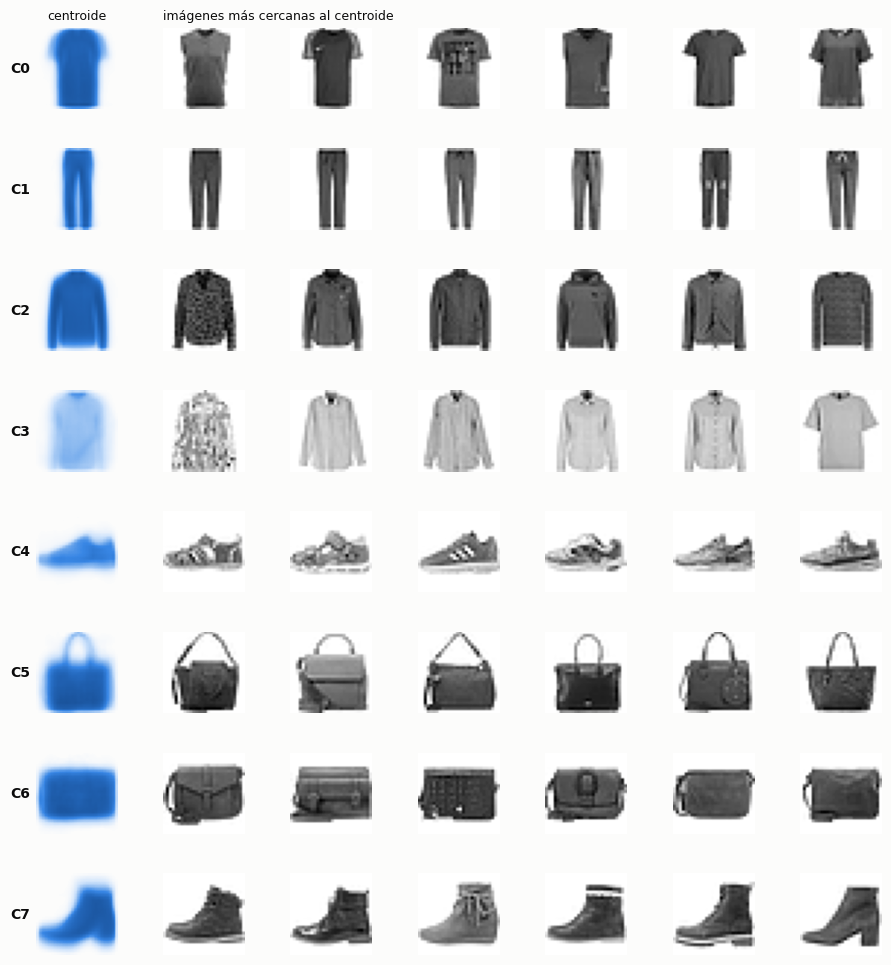

In [22]:
N_REP = 6
fig, axes = plt.subplots(K, N_REP + 1, figsize=(9, K * 1.25))
for c in range(K):
    miembros = np.flatnonzero(l_km == c)
    dist = np.linalg.norm(Z[miembros] - centroides[c], axis=1)
    cercanos = miembros[np.argsort(dist)[:N_REP]]
    axes[c, 0].imshow(a_imagen(centroides_px[c]), cmap=SEQ, vmin=0, vmax=1)
    for j, i in enumerate(cercanos, start=1):
        axes[c, j].imshow(a_imagen(X_work[i]), cmap="gray_r", vmin=0, vmax=1)
    axes[c, 0].set_ylabel(f"C{c}", rotation=0, ha="right", va="center", color=INK, fontweight="bold")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)
axes[0, 0].set_title("centroide", fontweight="normal", fontsize=9)
axes[0, 1].set_title("imágenes más cercanas al centroide", fontweight="normal", fontsize=9, loc="left")
plt.tight_layout()
plt.show()

**OBSERVACIONES**

| Cluster | Qué agrupa | Lectura |
|---|---|---|
| C0 | T-shirt 44%, Dress 23%, Shirt 15% | **Prendas superiores de manga corta**: el centroide es una remera. Las camisas y vestidos de manga corta caen acá. |
| C1 | Trouser 61%, Dress 34% | **Siluetas largas y angostas**: a 28x28 un vestido recto se parece más a un pantalón que a una remera. |
| C2 | Pullover 37%, Coat 36%, Shirt 21% | **Manga larga y tono oscuro**: el grupo de mayor intensidad (0,45). Pullover, Coat y Shirt no se distinguen. |
| C3 | Shirt 22%, T-shirt 19%, Pullover 17%, más sandalias y bolsos | **Prendas claras**: mezcla tipos de prenda y se define por el tono (intensidad 0,19), no por la forma. |
| C4 | Sneaker 52%, Sandal 39% | **Calzado bajo**: zapatillas y sandalias comparten silueta horizontal. |
| C5 | Bag 95% | **Bolsos con asa** visible arriba. |
| C6 | Bag 93% | **Bolsos rectangulares sin asa** (tipo bandolera o sobre). |
| C7 | Ankle boot 85% | **Calzado alto**: la caña de la bota lo separa del calzado bajo. |

- **Qué estructura captura:** el clustering agrupa por **silueta** (largo de manga, alto y ancho de la prenda, presencia de asa o de caña) y por **tono** (PC1), no por categoría comercial. Las categorías con silueta propia (Trouser, Bag, Ankle boot) se recuperan bien; las que comparten silueta (Pullover/Coat/Shirt, Sneaker/Sandal, Trouser/Dress) se mezclan.
- **Información nueva:** aparecen subgrupos que las etiquetas no tienen, como **bolsos con y sin asa** (C5/C6), y un grupo transversal de **prendas claras** (C3). Este último muestra una limitación de trabajar con píxeles: el color de la tela pesa tanto como la forma.

### Conclusiones

- **H1 (macro-grupos por silueta): se confirma.** Los clusters respetan las familias prendas superiores / calzado / bolsos / pantalones; con k = 8 cada familia se subdivide por largo de manga, altura del calzado o presencia de asa.
- **H2 (solapamiento Pullover / Coat / Shirt): se confirma.** Las tres clases caen juntas en C2 (y sus versiones claras en C3) con ambos algoritmos.
- **H3 (compresión con pocas componentes): se confirma.** 83 de 784 dimensiones retienen el 90% de la varianza y alcanzan para agrupar.
- Las métricas internas bajas (Silhouette ~0,2) indican que los datos forman un **continuo de formas** más que grupos aislados. Los clusters sirven para organizar el catálogo en familias visuales, pero no reemplazan a un clasificador supervisado para distinguir categorías finas como Shirt vs Coat.

## 4. Visualización e interpretación con UMAP

Se aplica **UMAP** sobre los **datos originales** (los 784 píxeles reescalados de `X_work`, sin pasar por PCA) para obtener una representación en 2D. A diferencia de PCA, UMAP es no lineal: construye un grafo de vecinos cercanos y busca un plano que preserve esas vecindades, por lo que muestra mejor la estructura local (grupos, continuidades, puntos aislados). Las distancias entre grupos lejanos, en cambio, no se deben leer literalmente.

Parámetros: `n_neighbors=15` (equilibrio entre estructura local y global), `min_dist=0.1` y distancia euclídea. La etiqueta no se usa para ajustar el embedding; solo para colorearlo después.

> Requiere `pip install umap-learn`.

In [23]:
import warnings

import umap

# Fijar random_state fuerza n_jobs=1; se silencia el aviso porque es intencional (reproducibilidad).
warnings.filterwarnings("ignore", message="n_jobs value .* overridden")

reductor = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=RANDOM_STATE)
E = reductor.fit_transform(X_work)
print(f"Embedding UMAP: {E.shape}")

Embedding UMAP: (10000, 2)


### 4.1 Estructura sin etiquetas

Primero se mira el embedding "a ciegas", como densidad de puntos, para identificar regiones y zonas densas sin la influencia de las etiquetas.

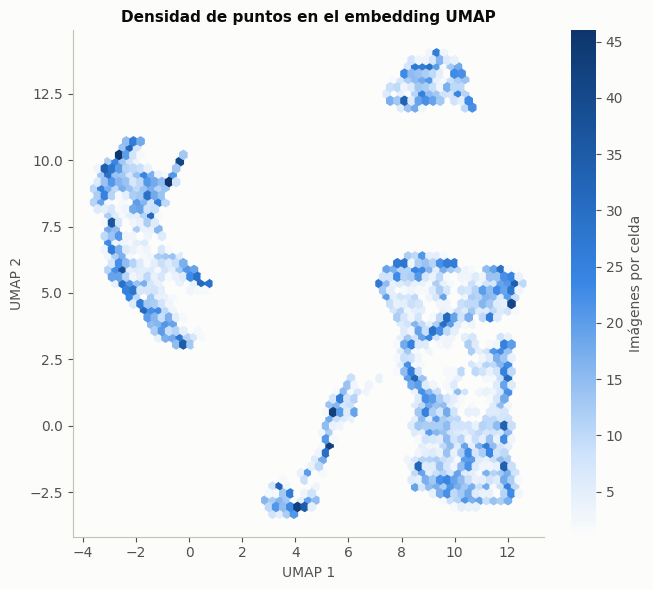

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 6))
hb = ax.hexbin(E[:, 0], E[:, 1], gridsize=60, cmap=SEQ, mincnt=1)
ax.set_title("Densidad de puntos en el embedding UMAP")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal")
fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04, label="Imágenes por celda").outline.set_visible(False)
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- Sin mirar etiquetas se distinguen **cuatro regiones**: una isla pequeña y completamente separada (arriba), una franja alargada a la izquierda, una franja angosta abajo al centro y un bloque grande a la derecha.
- La franja de abajo está unida al bloque de la derecha por un **puente de baja densidad**: hay imágenes intermedias entre ambas regiones.
- Dentro del bloque grande la densidad es despareja: hay núcleos densos en los extremos superior e inferior y una zona central más rala, lo que sugiere subgrupos que se tocan sin una frontera clara.

### 4.2 Embedding por clase y por cluster

Con 10 clases (y 8 clusters) un único gráfico con un color por grupo no se puede leer, así que se usan **paneles pequeños**: en cada uno se resalta un grupo sobre el resto de los puntos en gris.

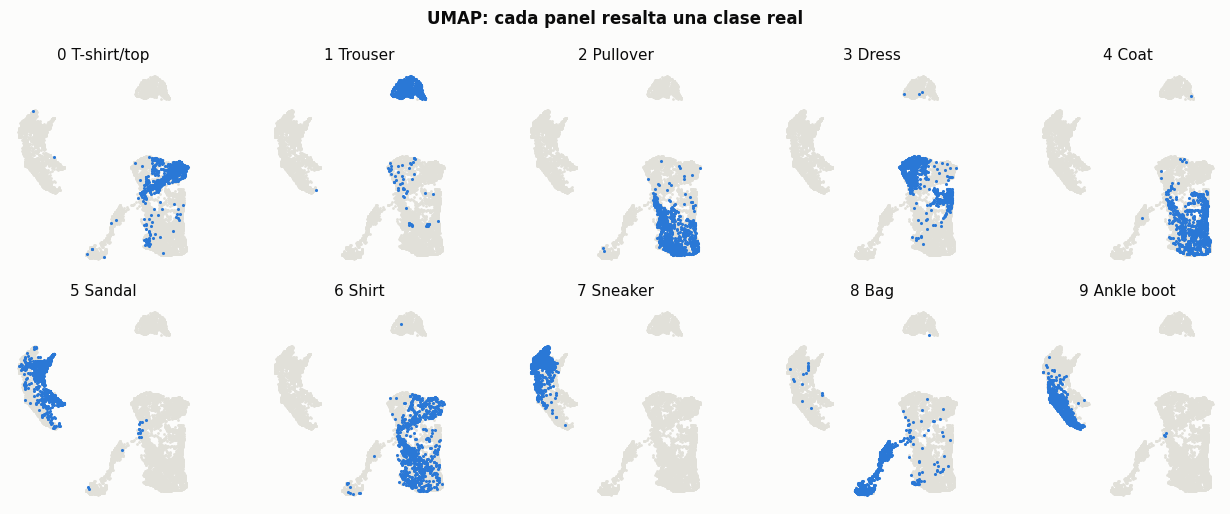

In [25]:
def paneles(grupos, nombres, titulo, ncols):
    nrows = int(np.ceil(len(nombres) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 2.6), sharex=True, sharey=True)
    for g, (ax, nombre) in enumerate(zip(axes.ravel(), nombres)):
        m = grupos == g
        ax.scatter(E[~m, 0], E[~m, 1], s=1, color=GRID, rasterized=True)
        ax.scatter(E[m, 0], E[m, 1], s=1.5, color=C_MAIN, rasterized=True)
        ax.set_title(nombre, fontweight="normal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.spines[:].set_visible(False)
        ax.set_aspect("equal")
    for ax in axes.ravel()[len(nombres):]:
        ax.set_visible(False)
    fig.suptitle(titulo, fontweight="bold")
    plt.tight_layout()
    plt.show()


paneles(y_work, [f"{k} {n}" for k, n in enumerate(CLASS_NAMES)], "UMAP: cada panel resalta una clase real", ncols=5)

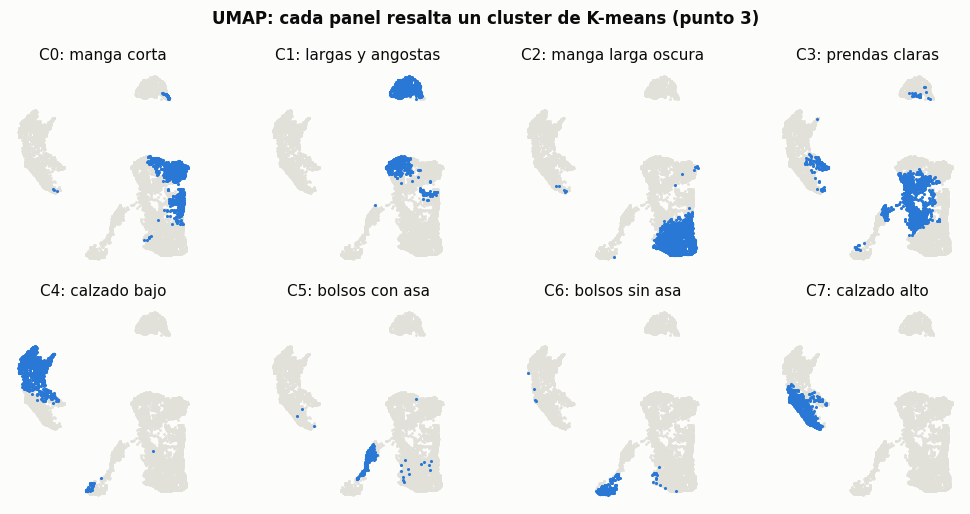

In [26]:
NOMBRES_CLUSTER = ["manga corta", "largas y angostas", "manga larga oscura", "prendas claras",
                   "calzado bajo", "bolsos con asa", "bolsos sin asa", "calzado alto"]  # ver tabla de 3.d
paneles(l_km, [f"C{c}: {n}" for c, n in enumerate(NOMBRES_CLUSTER)],
        "UMAP: cada panel resalta un cluster de K-means (punto 3)", ncols=4)

**OBSERVACIONES**
- **Las cuatro regiones son las macro-familias de H1:** la isla es **Trouser**, la franja izquierda es el **calzado**, la franja inferior son los **bolsos** y el bloque grande son las **prendas superiores** (T-shirt, Dress, Pullover, Coat, Shirt).
- **Trouser** es la clase mejor separada de todo el dataset: solo unos pocos pantalones caen dentro del bloque de prendas superiores.
- **El calzado forma un continuo** ordenado por la altura del zapato: Sneaker en un extremo, Ankle boot en el otro y Sandal en el medio, solapada con ambas. No son tres grupos discretos sino una gradación de formas.
- **Dentro del bloque de prendas superiores** hay un orden: T-shirt y Dress arriba (manga corta o sin manga), Pullover y Coat abajo (manga larga). **Shirt se dispersa por todo el bloque**, ya que hay camisas de manga corta, de manga larga, claras y oscuras: es la clase más ambigua. Esto confirma H2.
- **Relación con K-means:** la mayoría de los clusters son regiones contiguas del embedding (C2, C4, C5, C6, C7). Hay dos excepciones:
  - **C1** junta la isla de los pantalones con la zona de los vestidos, dos regiones que UMAP separa.
  - **C3 (prendas claras)** aparece repartido por el centro del bloque y con fragmentos en el calzado y los bolsos. Es un grupo definido por el tono que atraviesa la estructura de formas, no una región natural de los datos.

### 4.3 Puntos aislados

Se buscan las imágenes más aisladas del embedding: las de mayor distancia a su 15° vecino más cercano en el plano UMAP (el mismo `n_neighbors` usado para construirlo).

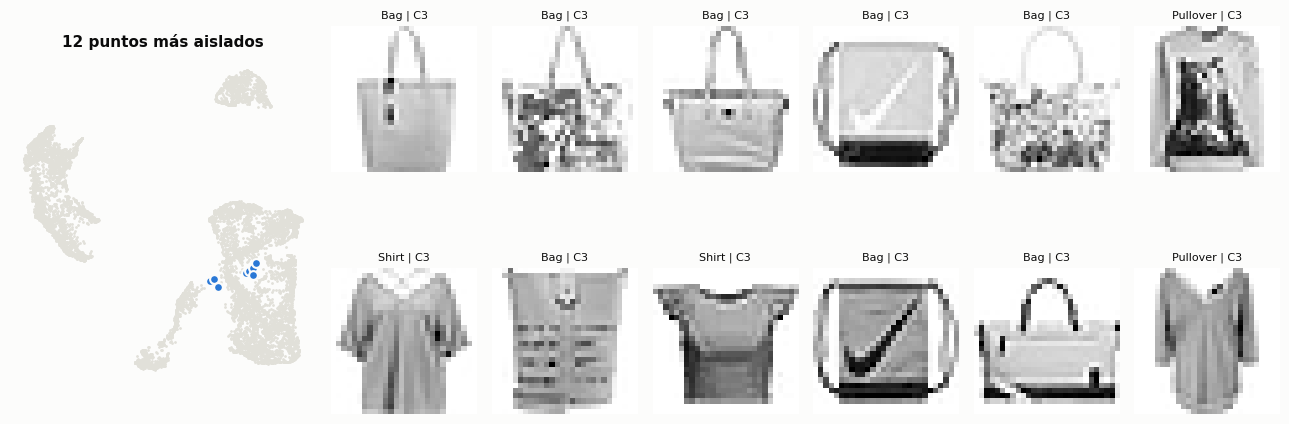

In [27]:
from sklearn.neighbors import NearestNeighbors

dist_k, _ = NearestNeighbors(n_neighbors=16).fit(E).kneighbors(E)  # el 1er vecino es el propio punto
aislamiento = dist_k[:, -1]
aislados = np.argsort(aislamiento)[::-1][:12]

fig = plt.figure(figsize=(13, 5))
gs = fig.add_gridspec(2, 8)
ax = fig.add_subplot(gs[:, :2])
ax.scatter(E[:, 0], E[:, 1], s=1, color=GRID, rasterized=True)
ax.scatter(E[aislados, 0], E[aislados, 1], s=40, color=C_MAIN, edgecolor=SURFACE, linewidth=1.5)
ax.set_xticks([]); ax.set_yticks([])
ax.spines[:].set_visible(False)
ax.set_aspect("equal")
ax.set_title("12 puntos más aislados")
for n, i in enumerate(aislados):
    a = fig.add_subplot(gs[n // 6, 2 + n % 6])
    a.imshow(a_imagen(X_work[i]), cmap="gray_r", vmin=0, vmax=1)
    a.set_title(f"{CLASS_NAMES[y_work[i]]} | C{l_km[i]}", fontsize=8, fontweight="normal")
    a.set_xticks([]); a.set_yticks([])
    a.spines[:].set_visible(False)
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- Los puntos más aislados no están dispersos al azar: se concentran en el **puente entre bolsos y prendas superiores** y en el borde del bloque donde ese puente se conecta. Son **bolsos claros con asa** y **prendas superiores claras y anchas**, todos asignados a C3.
- No son errores de etiqueta sino **imágenes ambiguas**: un bolso claro y grande tiene una silueta rectangular parecida a la de un buzo, y viceversa. Son los casos donde la representación por píxeles no alcanza para decidir a qué familia pertenecen.

### 4.4 Conclusiones de UMAP

- UMAP recupera **sin usar etiquetas** las cuatro familias de prendas (pantalones, calzado, bolsos y prendas superiores), con separaciones más nítidas que las que sugerían las métricas de Silhouette del punto 3. La estructura de los datos es más **no lineal** que lo que PCA + K-means puede capturar.
- Las clases con silueta propia forman regiones separadas. Las que comparten silueta forman **continuos** (calzado ordenado por altura; prendas superiores ordenadas por largo de manga) en vez de grupos aislados. Esto explica por qué ningún clustering particional puede alcanzar una concordancia alta con las 10 clases.
- Frente a K-means, UMAP muestra dos limitaciones de la solución elegida: une Trouser y Dress (C1), que son regiones distintas, y crea un grupo por tono (C3) que no se corresponde con la estructura de formas.
- UMAP es una herramienta de **visualización**: preserva vecindades locales pero distorsiona distancias y tamaños globales, por lo que las conclusiones se apoyan en qué puntos son vecinos y no en cuán lejos están las regiones entre sí.